# e2_64x64_4_layered_aug_SGD

This is the baseline experiment. It includes following components in the model:
* 64x64x3 input size
* Data Augmentations
* 4 Convolutional Layers
* Pooling Layer after each convolutional Layer
* SGD optimizer

### Importing required modules
Importing basic modules for training:
* torch
* datasets and transform
* dataloader

Importing Architecture:
* Architecture

Importing custom utils
* Trainer
* tester
* gen_line_charts

In [1]:
# torch and modules
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Main architecture
from Architecture import Architecture

# custom utils and modules
from modules.trainer import Trainer
from modules.tester import test
from modules.charts import gen_line_charts

## Load data
Use datasets, transforms and DataLoader to:
* LoadData
* Resize image to 64x64
* Randomly flip images horizontally
* Randomly rotate image by +-10 deg
* Add Color Jitters
* Randomly move the image
* transform to tensor
* Add a small Random Erasing between 2% to 10% erasing

For all three datasets: train, val and test

In [2]:
image_size = 64

aug_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.5
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.12, 0.12),
        scale=(0.8, 1.2)
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.10),
    )
])

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])


# make train sets
train_datasets = datasets.ImageFolder("./datasets/train", aug_transform)
train_loader = DataLoader(
    dataset=train_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# make validation sets
val_datasets = datasets.ImageFolder("./datasets/val", transform)
val_loader = DataLoader(
    dataset=val_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# make test sets
test_datasets = datasets.ImageFolder("./datasets/test", transform)
test_loader = DataLoader(
    dataset=test_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

## Define and Use Architecture
define a model by calling Architecture class and add layers to it:
* 4 Convolutional Layer each followed with pooling layer
* 1 Flatten Layer followed with a 128 fully connected neural network
* 1 Linear layer to generate 3 class logits

In [3]:
model = Architecture()

Using function to loop adding 4 convolutional layers with pooling layer 

In [4]:
def add_conv_layers(layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = image_size
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool:
            model.add(nn.MaxPool2d(2,2))
            size = size/2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

Call the `add_conv_layers()` and store parameters

In [5]:
conv_params, out_channels, size = add_conv_layers(4, 0)

# print conv params and out_channels
print(f"Total Trainable Parameters: {conv_params}")
print(f"Final Features: {out_channels}")
print(f"Final Feature size: {size}x{size}")

Total Trainable Parameters: 24768
Final Features: 64
Final Feature size: 64x64


use `model.add()` to add:
* Flatten Layer (64x4x4)
* Hidden Layer (64x4x4->128)
* Output Layer (128->3)

In [6]:
# calculate input
n_in = out_channels*size*size
print(f"Input vector size = {n_in}")

model.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
    nn.ReLU()
)

Input vector size = 262144


Calculating total parameters of the model

In [7]:
total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {total_trainable_parameters}")

Total trainable parameters = 33554947


### Defining optimizer and Criterion
Optimizer:
* SGD
* learning rate = 2e-3
* no weight decay

Critetion:
* nn.CrossEntropy()

In [8]:
# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=2e-3)
# criterion 
criterion = nn.CrossEntropyLoss()

## Train the model
Use Trainer Function to train the complete model for 100 epochs

In [9]:
trainer = Trainer(
    model,
    train_loader,
    val_loader,
    optimizer,
    "cuda",
    criterion
)

In [10]:
save_path = "./experiments/e2_64x64_4_layers_aug_SGD"

In [11]:
metrics = trainer.fit(100, save_path, 1)

EPOCH 5 completed | Training Loss = 0.9933882791604569 | Validation Loss = 0.9810925881067912
EPOCH 10 completed | Training Loss = 0.9658895819934447 | Validation Loss = 0.9951612075169881
EPOCH 15 completed | Training Loss = 0.9367716463644113 | Validation Loss = 0.9857892711957296
EPOCH 20 completed | Training Loss = 0.9257178555673627 | Validation Loss = 0.903931458791097
EPOCH 25 completed | Training Loss = 0.9194907786241219 | Validation Loss = 0.8824425160884857
EPOCH 30 completed | Training Loss = 0.8883694517078684 | Validation Loss = 0.9438299377759297
EPOCH 35 completed | Training Loss = 0.8958371993321091 | Validation Loss = 0.8950849890708923
EPOCH 40 completed | Training Loss = 0.8620243499528116 | Validation Loss = 1.1908669700225194
EPOCH 45 completed | Training Loss = 0.8489687967656264 | Validation Loss = 1.2072164873282114
EPOCH 50 completed | Training Loss = 0.7466074139324587 | Validation Loss = 1.1075733959674836
EPOCH 55 completed | Training Loss = 0.7289512375397

## Plot the training metrics
Plotting line chart of training metrics that shows curves of loss, accuracy, precision, recall and f1-score for training set and validation set. 

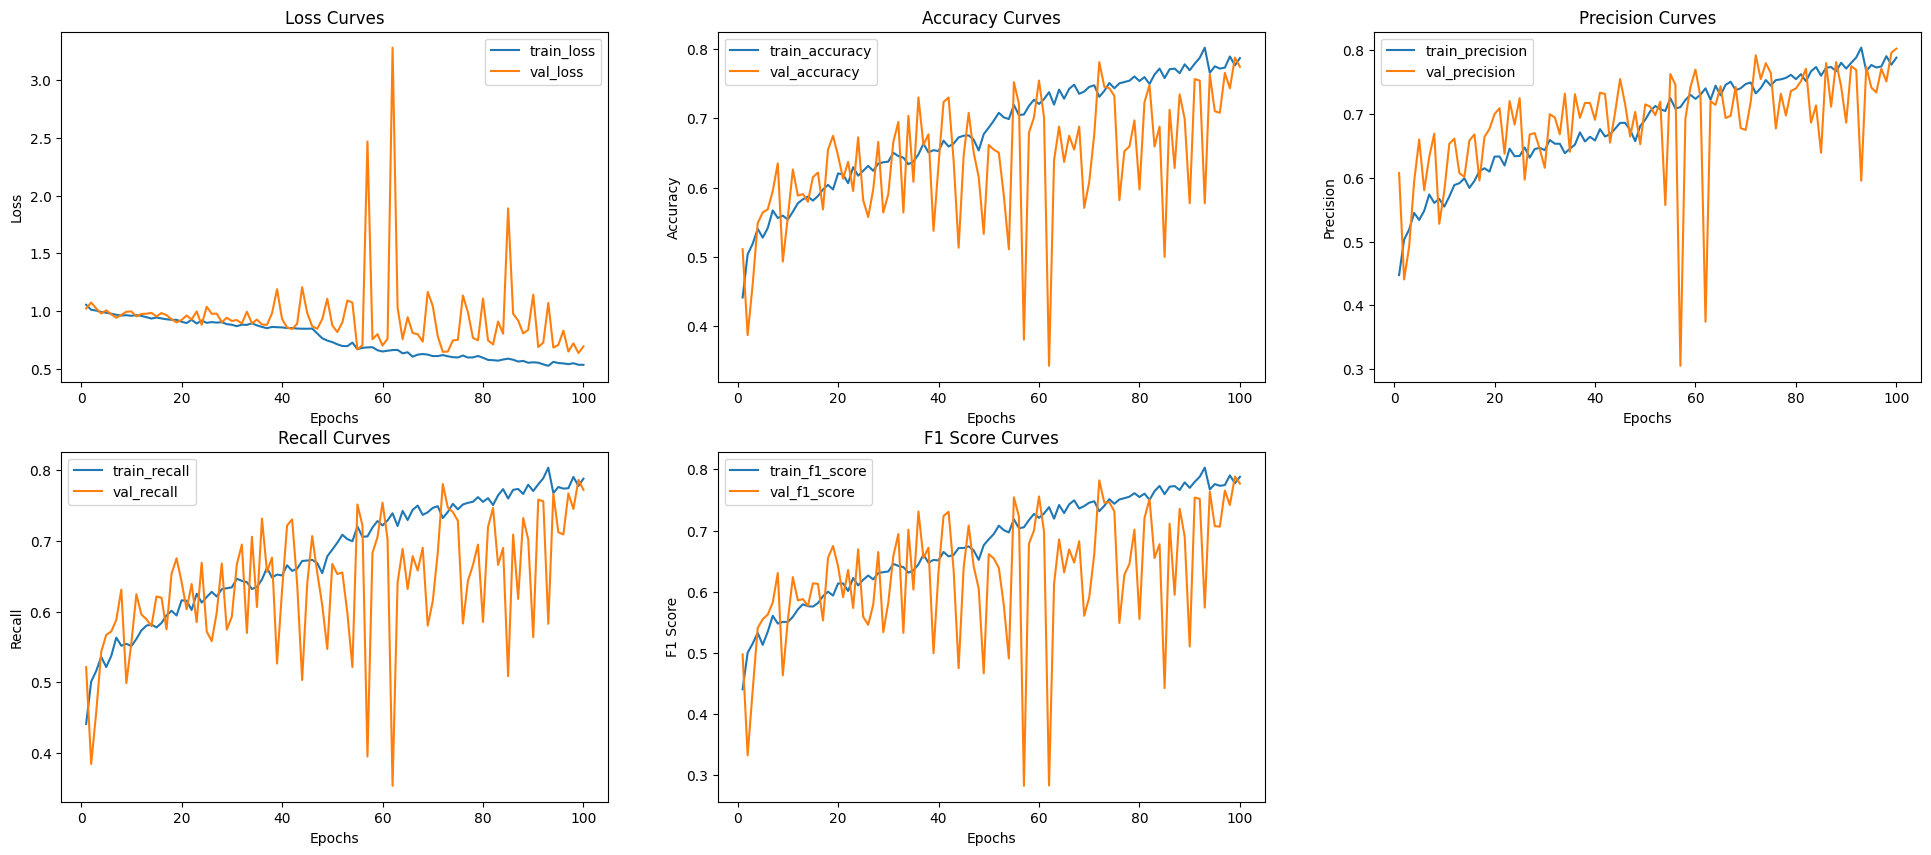

In [12]:
gen_line_charts(metrics, save_path, "training_metrics_graph.png", ["train_", "val_"])

### Model Evaluation
The loss curve on training set tends to decrease approaching zero. The training loss decreased till approximately 0.53. The model is slowly learning and adapting to the patterns on the training set. The validation set shows decrease in the loss approximately overlapping training loss curve till epoch 40. The validation loss curve starts showing fluctuations from around epoch 35. The fluctuations are extreme where it reached above loss 3.

The accuracy, precision, recall and F1-score curves shows similar growth having some overlap between training and validation set. The curves on training set shows slow and smooth learning approximating towards 0.8. The curves on validation set also tries approximate towads 0.8 but with extreme fluctuations creating deep valleys. Despite having peaks and valleys the validation set is trying to overlap and go together with the training curve on some peak points.

Overall the model shows significant improvement over the baseline experiment. The appication of augmentation reduced the visible gap between the training curves and validation curves, indicating the reduction in overfitting. Despite the these improvements, validation curves still shows high unstability. The model also tends to converge slower comparatively to the baseline experiment as the training loss is still around 0.5 and the training metrics are approximating towards 0.8 in 100 epochs.